In [5]:
print("hello worlds!")

hello worlds!


In [ ]:
!pip install numpy

In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Diwali Sales Data.csv', encoding= 'unicode_escape')
## we use unicode_escape in order to avoid encoding eroor. 

In [8]:
df.shape

(11251, 15)

In [ ]:
df.head(10)

In [ ]:
df.info()

In [11]:
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

In [ ]:
pd.isnull(df).sum()
## to check for any null values.

In [13]:
df.dropna(inplace=True) ## dropping the null values

In [ ]:
df.info()

In [16]:
df['Amount'] = df['Amount']. astype(int)

In [ ]:
df[['Age','Orders','Amount']].describe()

### Exploratory Data Analysis

#### Gender

In [26]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [ ]:
ax = sns.countplot(x= 'Gender', data= df)
for bars in ax.containers:
        ax.bar_label(bars)

In [ ]:
sales_gen=df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.barplot(x='Gender',y='Amount', data= sales_gen)
## The graph shows that most of the byers are female and even the purchasing power of female are grater then men.

#### Age

In [ ]:
ax = sns.countplot(data= df, x= 'Age Group', hue= 'Gender')
for bars in ax.containers:
        ax.bar_label(bars)

<Axes: xlabel='Age Group', ylabel='Amount'>

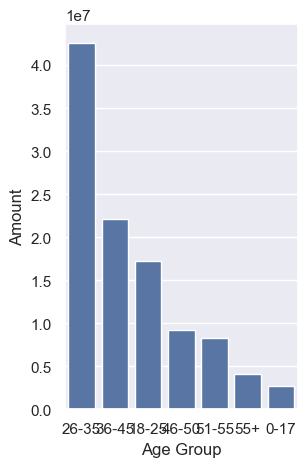

In [11]:
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.barplot(x='Age Group', y='Amount', data= sales_age)

most of the buyers are from 26-35 age group

##### State

<Axes: xlabel='State', ylabel='Orders'>

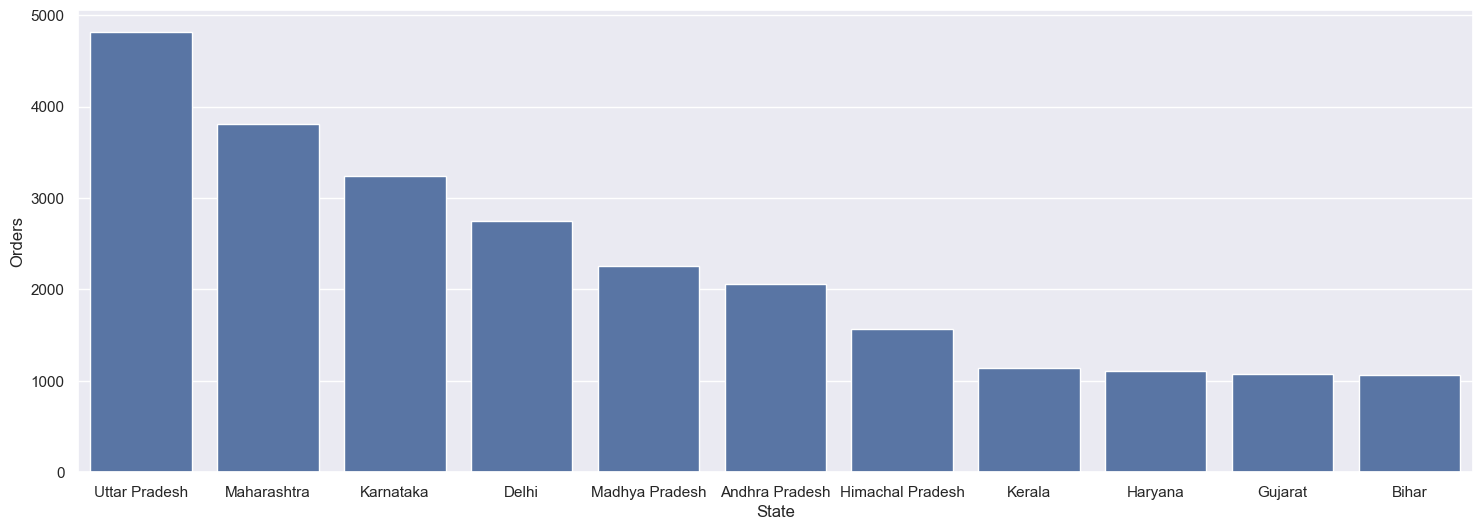

In [5]:
## top numbers of orders from top 10 states
sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(11)

sns.set(rc={'figure.figsize':(18,6)})
sns.barplot(data= sales_state, x = 'State', y = 'Orders')


<Axes: xlabel='State', ylabel='Amount'>

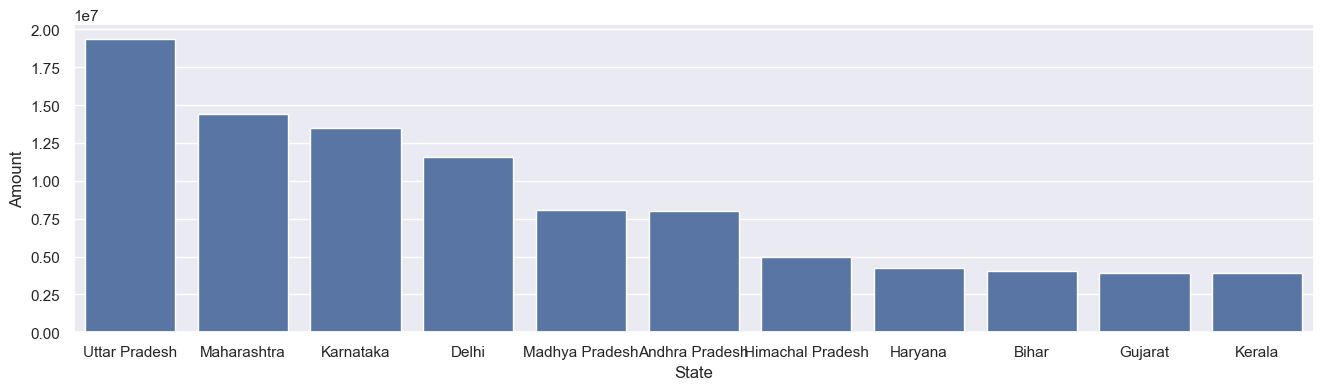

In [25]:
## total amount/sales from top 10 states
sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(11)

sns.set(rc={'figure.figsize':(16,4)})
sns.barplot(data= sales_state, x ='State', y='Amount')

here most of the orders and total amount spent on is from Uttar Pradesh, Maharashtra, and Karnataka. followed by other stsates 

#### Marital Status

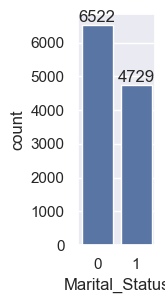

In [23]:
ax = sns.countplot(data = df, x = 'Marital_Status')

sns.set(rc={'figure.figsize':(2,4)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

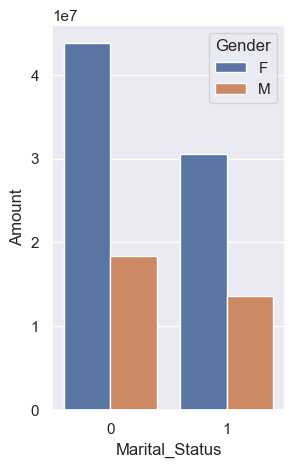

In [10]:
sales_state = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(3,5)})
sns.barplot(data = sales_state, x = 'Marital_Status',y= 'Amount', hue='Gender')

form above visualization we can conclude that most of the buyers as married women and they have high purchasing power.

### Occupation

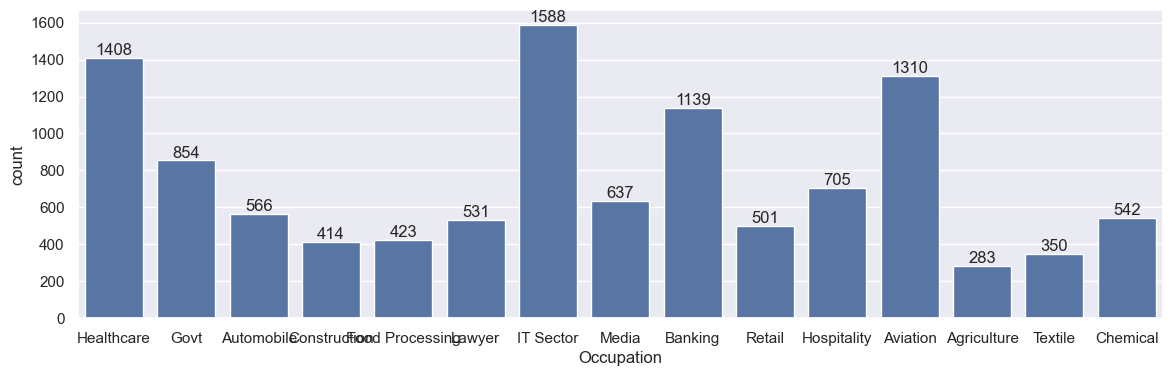

In [19]:
sns.set(rc={'figure.figsize':(14,4)})
ax = sns.countplot(data = df, x = 'Occupation')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

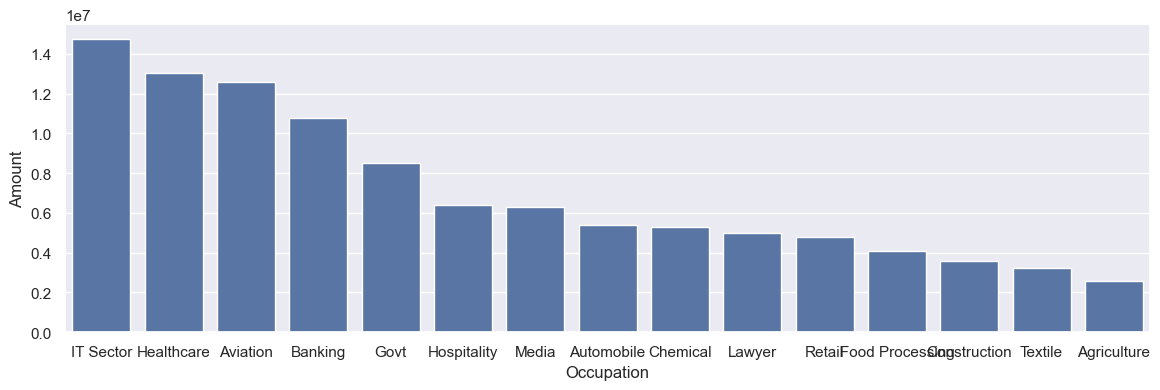

In [18]:
sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(14,4)})
sns.barplot(data = sales_state, x = 'Occupation',y= 'Amount')

<Axes: xlabel='Occupation', ylabel='Amount'>

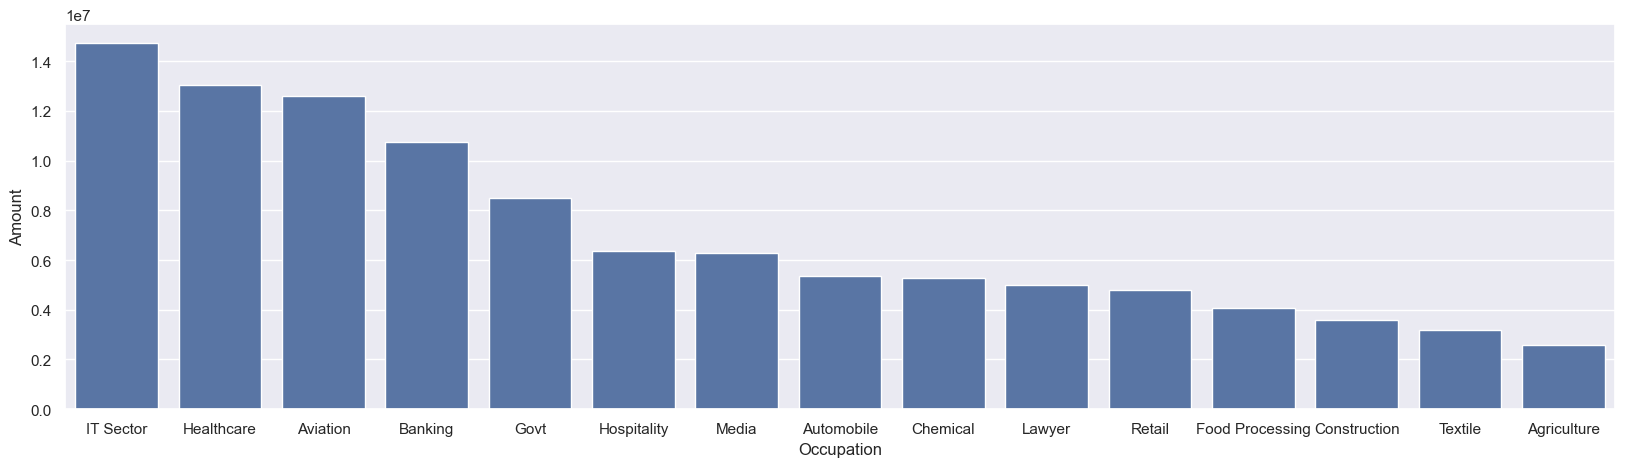

In [26]:
sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Occupation',y= 'Amount')

*From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector*

#### Product Category

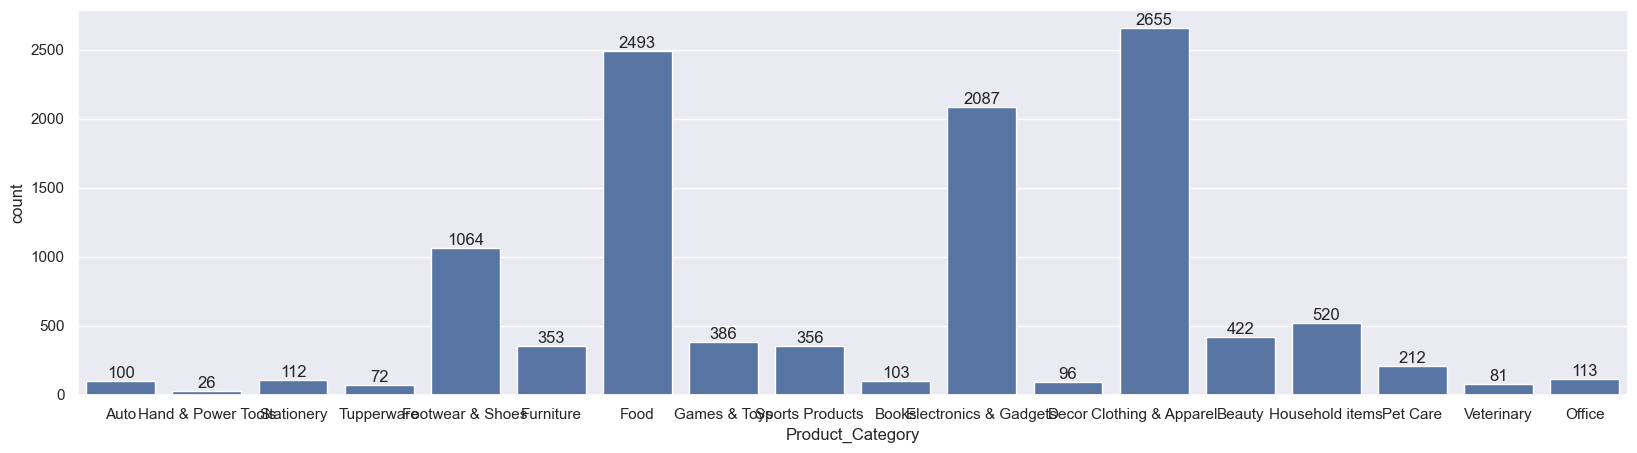

In [27]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Product_Category')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

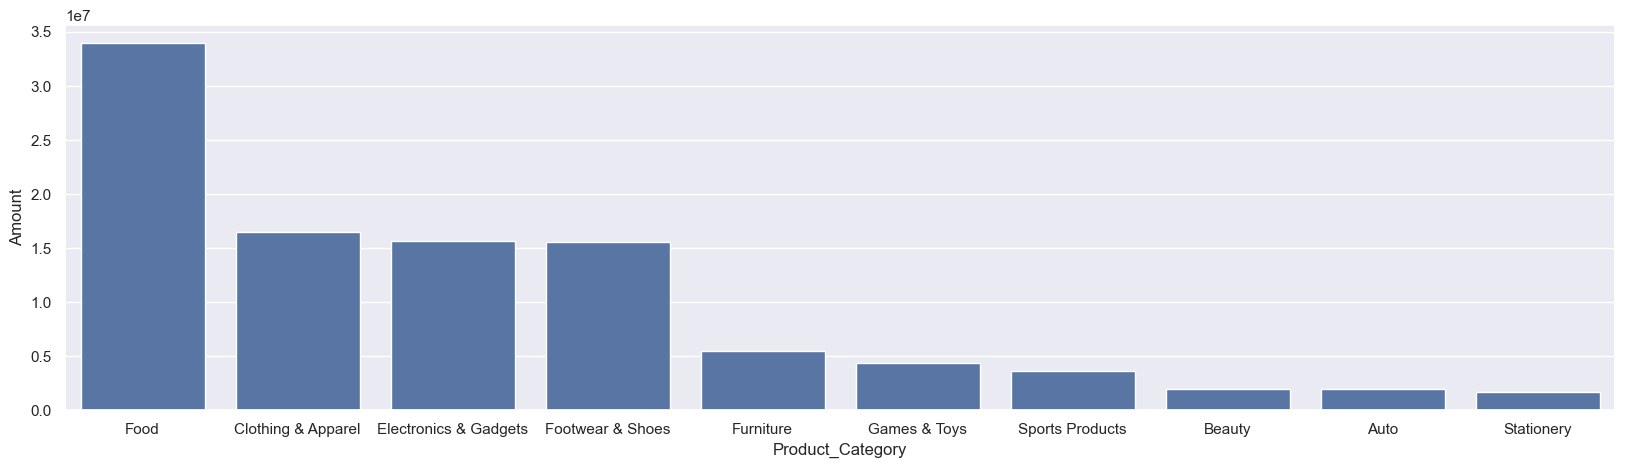

In [28]:
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_Category',y= 'Amount')

*From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category*

<Axes: xlabel='Product_ID', ylabel='Orders'>

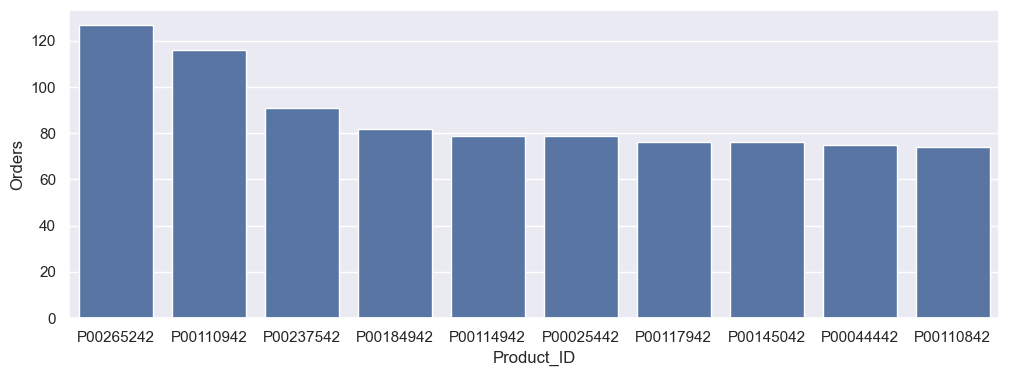

In [33]:
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(12,4)})
sns.barplot(data = sales_state, x = 'Product_ID',y= 'Orders')

<Axes: xlabel='Product_ID'>

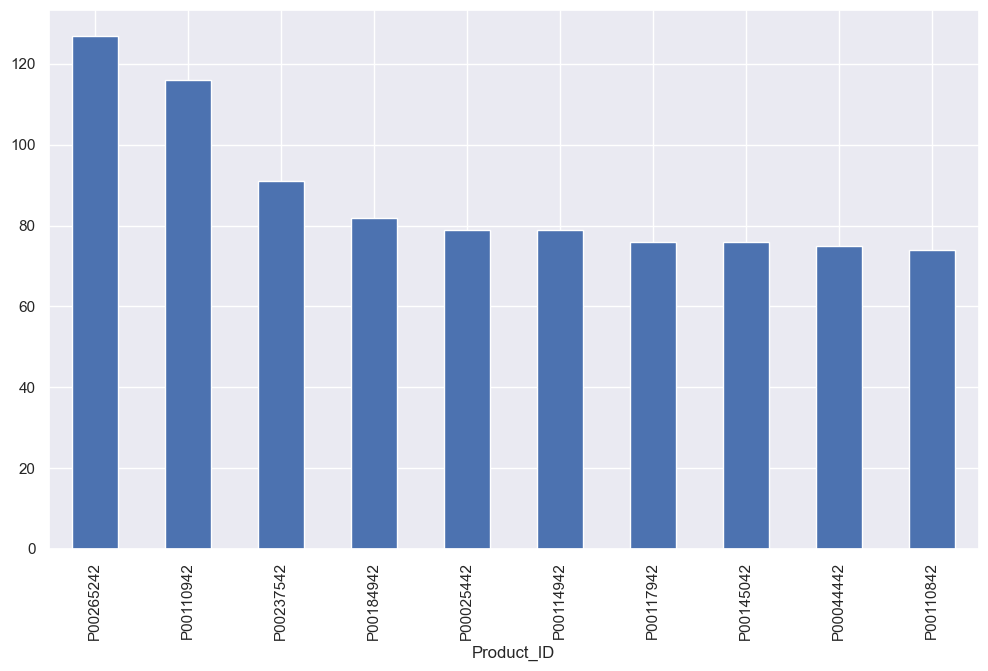

In [32]:
# top 10 most sold products (same thing as above)

fig1, ax1 = plt.subplots(figsize=(12,7))
df.groupby('Product_ID')['Orders'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

#### Conclusion
*Married women age group 26-35 yrs from UP,  Maharastra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category*